# SIH26078 - Extreme-weather tracking (GNN) + amplitude-preserving downscaling (diffusion)
Event: Cyclone Amphan (May 2020). Kaggle settings: GPU T4, Internet ON. Run cells top to bottom.
Attach your Kaggle Dataset(s) with the ERA5 / IBTrACS / (optional) HRES files via "Add Data".

In [1]:
# ============ 1. SETUP ============
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gcsfs", "zarr", "torch_geometric", "diffusers", "accelerate"], check=False)

import os, glob, json, math, random, warnings
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings("ignore")

INPUT_DIR, OUT = "/kaggle/input", "/kaggle/working"
EVENT = "AMPHAN"
WIDE = dict(lat=(5, 29), lon=(77, 98))        # data box = your 8-26N / 80-95E box + ~3 deg margin
HRES_INITS = ["2020-05-13T00", "2020-05-13T12", "2020-05-14T00", "2020-05-14T12", "2020-05-15T00", "2020-05-15T12"]
LEAD_DAYS = (3, 10)
TRAIN_YEARS, TRAIN_MONTHS = range(2015, 2020), (5, 11)     # Stage-2 training (ERA5 hourly)
EVAL_START, EVAL_END = "2020-05-13", "2020-05-25T18"      # Amphan hold-out
SCALE, CROP = 4, 64                                        # downscaling factor, crop size (pixels)
GNN_EPOCHS, UNET_STEPS, DIFF_STEPS = 30, 3000, 6000
N_MEMBERS, SAMPLE_STEPS = 4, 40
R_EARTH = 6.371e6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 677.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00


In [2]:
# ============ 2. DATA HELPERS + FILE INVENTORY ============
# Standardize variable name mapping across all ERA5 and HRES sources
VAR_MAP = {
    "mean_sea_level_pressure": "msl",
    "10m_u_component_of_wind": "u10",
    "10m_v_component_of_wind": "v10",
    "surface_pressure": "sp",
    "total_precipitation": "tp",
    "2m_temperature": "t2m",
    "2m_dewpoint_temperature": "d2m",
    "vertically_integrated_moisture_divergence": "vimd"
}

def std_ds(ds, crop=True):
    """Make any ERA5 / WB2 file look the same: time, latitude (ascending), longitude, cropped."""
    if "valid_time" in ds.dims:
        ds = ds.drop_vars("time", errors="ignore").rename({"valid_time": "time"})
    ds = ds.rename({k: v for k, v in {"lat": "latitude", "lon": "longitude"}.items() if k in ds.dims})
    ds = ds.rename({k: v for k, v in VAR_MAP.items() if k in ds})
    ds = ds.drop_vars(["expver", "number"], errors="ignore").sortby("latitude")
    
    # Expand scalar time coordinate to 1D dimension so open_mfdataset can concatenate along time
    if "time" in ds.coords and ds["time"].ndim == 0:
        ds = ds.expand_dims("time")
        
    if crop and "latitude" in ds.dims and "longitude" in ds.dims:
        ds = ds.sel(latitude=slice(*WIDE["lat"]), longitude=slice(*WIDE["lon"]))
    return ds

def inventory():
    rows = []
    for f in sorted(glob.glob(f"{INPUT_DIR}/**/*.nc", recursive=True)):
        try:
            try:
                raw = xr.open_dataset(f)
            except Exception:
                raw = xr.open_dataset(f, decode_times=False)
            d = std_ds(raw, crop=False)
            # Use np.atleast_1d to prevent scalar DatetimeIndex crashes
            t = pd.DatetimeIndex(np.atleast_1d(d["time"].values)) if "time" in d.coords else []
            rows.append(dict(
                file=f.replace(INPUT_DIR, ""), 
                vars=list(d.data_vars), 
                n_time=len(t),
                start=str(t.min())[:10] if len(t) else "-", 
                end=str(t.max())[:10] if len(t) else "-", 
                path=f
            ))
        except Exception as e:
            rows.append(dict(file=f.replace(INPUT_DIR, ""), vars=["ERROR " + str(e)[:60]], n_time=0, start="", end="", path=f))
    return pd.DataFrame(rows)

def files_where(inv, pred):
    return [r.path for r in inv.itertuples() if pred(set(r.vars))]

def load_era5(files):
    ds = xr.open_mfdataset(files, preprocess=std_ds, combine="by_coords", chunks={}).sortby("time")
    return ds.isel(time=np.where(~ds.get_index("time").duplicated())[0])

def to_hpa(ds):
    if float(ds["msl"].isel(time=0).mean() if "time" in ds["msl"].dims else ds["msl"].mean()) > 2000:
        ds["msl"] = ds["msl"] / 100.0
    return ds

In [3]:
# ============ 3. NUMPY UTILITIES: climatology, EFI, features, graph, tracker, IBTrACS ============
class Clim:
    """30-yr baseline -> per-node percentile + z-score for any valid time (same hour, +-7 day-of-year window)."""
    def __init__(self, base):
        self.msl = base["msl"].values.astype("float32")
        self.wsp = np.hypot(base["u10"].values, base["v10"].values).astype("float32")
        t = pd.DatetimeIndex(base["time"].values)
        self.doy, self.hr = t.dayofyear.values, t.hour.values
    def stats(self, name, x, valid, half=7):
        v = pd.Timestamp(valid)
        m = (self.hr == v.hour) & (np.abs(self.doy - v.dayofyear) <= half)
        S = getattr(self, name)[m]
        if len(S) < 30:
            raise ValueError(f"Only {len(S)} baseline samples for {v} - baseline must cover this date/hour")
        less, eq = (S < x[None]).sum(0), (S == x[None]).sum(0)
        p = (less + 0.5 * eq + 0.5) / (len(S) + 1)               # empirical climate CDF value of the forecast, in (0,1)
        z = (x - S.mean(0)) / (S.std(0) + 1e-3)
        return z, p

def efi_from_p(p):
    """Extreme Forecast Index of one forecast value whose climate-CDF value is p:  EFI = (4/pi)*asin(sqrt(p)) - 1.
    (Closed form of ECMWF's EFI integral for a single member; ensemble EFI = mean of member EFIs.)  -1..+1"""
    return 4 / np.pi * np.arcsin(np.sqrt(p)) - 1

def rel_vort(u, v):
    dlat, dlon = np.deg2rad(LAT[1] - LAT[0]), np.deg2rad(LON[1] - LON[0])
    c = np.cos(np.deg2rad(LAT))[:, None]
    return np.gradient(v, axis=1) / (R_EARTH * dlon * c) - np.gradient(u, axis=0) / (R_EARTH * dlat)

def node_features(msl, u, v, valid, clim):
    wsp = np.hypot(u, v)
    z_m, p_m = clim.stats("msl", msl, valid)
    _, p_w = clim.stats("wsp", wsp, valid)
    F = dict(efi_m=efi_from_p(p_m), efi_w=efi_from_p(p_w), z_m=z_m, vort=rel_vort(u, v), msl=msl, wsp=wsp)
    X = np.stack([F["efi_m"], F["efi_w"], np.clip(z_m, -8, 8) / 4, u / 15, v / 15, wsp / 20,
                  np.clip(F["vort"] * 1e4, -10, 10) / 5], -1)
    return X.reshape(-1, X.shape[-1]).astype("float32"), F

def pseudo_label(F):
    """Weak supervision: deep pressure anomaly + extreme wind. (Swap for IBTrACS-radius labels if you have many storms.)"""
    return ((F["efi_m"] < -0.90) & (F["efi_w"] > 0.75) & (F["z_m"] < -3)).astype("float32").ravel()

def build_graph_np(k_local=8, k_far=8, stride=4):
    """Sphere-aware multi-scale graph: kNN in 3-D (no lat/lon distortion) + long-range links through a coarse sub-mesh."""
    la, lo = np.meshgrid(LAT, LON, indexing="ij")
    phi, lam = np.deg2rad(la).ravel(), np.deg2rad(lo).ravel()
    xyz = np.stack([np.cos(phi) * np.cos(lam), np.cos(phi) * np.sin(lam), np.sin(phi)], 1)
    n = len(xyz)
    coarse = np.arange(n).reshape(la.shape)[::stride, ::stride].ravel()
    _, i1 = NearestNeighbors(n_neighbors=k_local + 1).fit(xyz).kneighbors(xyz)
    _, i2 = NearestNeighbors(n_neighbors=k_far).fit(xyz[coarse]).kneighbors(xyz)
    _, i3 = NearestNeighbors(n_neighbors=k_local + 1).fit(xyz[coarse]).kneighbors(xyz[coarse])
    e = np.concatenate([np.stack([i1[:, 1:].ravel(), np.repeat(np.arange(n), k_local)]),
                        np.stack([coarse[i2].ravel(), np.repeat(np.arange(n), k_far)]),
                        np.stack([coarse[i3[:, 1:]].ravel(), np.repeat(coarse, k_local)])], 1)
    e = e[:, e[0] != e[1]]
    return np.unique(e, axis=1)

def severity(min_msl_hpa, max_wind):
    if max_wind >= 24.5 or min_msl_hpa < 985: return "severe"
    if max_wind >= 17.0 or min_msl_hpa < 995: return "moderate"
    return "low"
SEV_RANK = {"low": 0, "moderate": 1, "severe": 2}

def detect(prob, F, prev=None, thr=0.5, min_nodes=8, gate_deg=6.0, pad=1.5):
    """GNN node probabilities -> connected blob -> bbox + centre (min pressure) + intensity. prev = (lat,lon) for continuity."""
    P = prob.reshape(len(LAT), len(LON))
    lab, n = ndimage.label(P > thr, structure=np.ones((3, 3)))
    cands = []
    for i in range(1, n + 1):
        m = lab == i
        if m.sum() < min_nodes: continue
        iy, ix = np.unravel_index(np.argmin(np.where(m, F["msl"], np.inf)), m.shape)
        cands.append(dict(m=m, iy=iy, ix=ix, score=float(P[m].sum())))
    if not cands: return None
    if prev is not None:
        near = [c for c in cands if np.hypot(LAT[c["iy"]] - prev[0], LON[c["ix"]] - prev[1]) <= gate_deg]
        cands = near or cands
    c = max(cands, key=lambda c: c["score"])
    ys, xs = np.where(c["m"])
    mn, mx = float(F["msl"][c["m"]].min()), float(F["wsp"][c["m"]].max())
    return dict(lat=float(LAT[c["iy"]]), lon=float(LON[c["ix"]]),
                bbox=[float(max(LAT[ys.min()] - pad, LAT[0])), float(min(LAT[ys.max()] + pad, LAT[-1])),
                      float(max(LON[xs.min()] - pad, LON[0])), float(min(LON[xs.max()] + pad, LON[-1]))],
                min_msl_hpa=mn, max_wind_ms=mx, severity=severity(mn, mx))

def track_sequence(fields, times):
    out, prev = [], None
    for (msl, u, v), t in zip(fields, times):
        X, F = node_features(msl, u, v, t, CLIM)
        d = detect(gnn_predict(X), F, prev)
        if d:
            d["t"] = str(pd.Timestamp(t)); prev = (d["lat"], d["lon"])
        out.append(d)
    return out

def haversine(lat1, lon1, lat2, lon2):
    p1, p2 = np.deg2rad(lat1), np.deg2rad(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.deg2rad(lon2 - lon1) / 2) ** 2
    return 2 * R_EARTH / 1000 * np.arcsin(np.sqrt(a))

def load_ibtracs():
    for f in glob.glob(f"{INPUT_DIR}/**/*.csv", recursive=True):
        try: df = pd.read_csv(f, low_memory=False)
        except Exception: continue
        df = df.rename(columns={"Timestamp": "ISO_TIME"})
        if not {"ISO_TIME", "LAT", "LON"} <= set(df.columns): continue
        df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")
        for c in ["LAT", "LON", "WMO_WIND", "WMO_PRES", "USA_WIND", "USA_PRES"]:
            if c in df: df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.dropna(subset=["ISO_TIME", "LAT", "LON"])          # also drops IBTrACS' units row
        if "NAME" in df and (df["NAME"].astype(str).str.upper() == EVENT).any():
            df = df[df["NAME"].astype(str).str.upper() == EVENT]
        df = df[(df.ISO_TIME >= "2020-05-10") & (df.ISO_TIME <= "2020-05-27")].sort_values("ISO_TIME")
        if len(df) > 3: return df.reset_index(drop=True)
    raise FileNotFoundError("No IBTrACS csv with ISO_TIME/LAT/LON for Amphan found under /kaggle/input")

def best_track_at(bt, times):
    tt = bt.ISO_TIME.values.astype("datetime64[ns]").astype("int64").astype(float)
    q = np.array(times, dtype="datetime64[ns]").astype("int64").astype(float)
    return np.interp(q, tt, bt.LAT.values), np.interp(q, tt, bt.LON.values), (q >= tt.min()) & (q <= tt.max())

def track_errors(track, times, bt):
    lat, lon, alive = best_track_at(bt, times)
    rows = []
    for d, t, la, lo, al in zip(track, times, lat, lon, alive):
        rows.append(dict(t=pd.Timestamp(t), alive=bool(al), detected=d is not None,
                         err_km=float(haversine(d["lat"], d["lon"], la, lo)) if (d and al) else np.nan))
    return pd.DataFrame(rows)

In [4]:
# ============ 4. LOAD YOUR DATA (auto-detects files) ============
inv = inventory()
print(inv.drop(columns="path").to_string())
print("\nCSV files:", [p.replace(INPUT_DIR, "") for p in glob.glob(f"{INPUT_DIR}/**/*.csv", recursive=True)])

# 1. Select the 30 yearly 6-hourly files for 1991-2020 (skips the 0-time mean_std file)
BASE_FILES = sorted([
    r.path for r in inv.itertuples() 
    if ("2_ERA5_Climatology" in r.path or "era5_6h" in r.path) 
    and r.n_time > 0 
    and "mean_std" not in r.path
])

# 2. Select the 11 surface training & test NetCDF files
SURF_FILES = sorted([
    r.path for r in inv.itertuples() 
    if ("3_ERA5_Surface" in r.path or "era5_arco_sfc" in r.path) 
    and r.n_time > 0
])

# 3. Select local HRES forecast files
HRES_FILES = sorted([
    r.path for r in inv.itertuples() 
    if ("1_IFS_HRES" in r.path or "ifs_hres" in r.path) 
    and "ERROR" not in str(r.vars)
])

print(f"\nDiscovered: {len(BASE_FILES)} baseline files, {len(SURF_FILES)} surface files, {len(HRES_FILES)} HRES forecast files")

assert BASE_FILES, "No ERA5 baseline files found in 2_ERA5_Climatology."
assert SURF_FILES, "No ERA5 surface files found in 3_ERA5_Surface."

# Load baseline and verify 30-year span
base = to_hpa(load_era5(BASE_FILES)[["msl", "u10", "v10"]]).astype("float32").load()
LAT, LON = base.latitude.values, base.longitude.values
NY, NX = len(LAT), len(LON)
print("Baseline:", base.time.dt.year.min().item(), "-", base.time.dt.year.max().item(), 
      "| Steps:", base.sizes["time"], "| Grid:", NY, "x", NX)
assert base.time.dt.year.max() - base.time.dt.year.min() >= 25, "Baseline should span ~30 years"

def align(ds):
    if ds.latitude.size != NY or ds.longitude.size != NX or not (np.allclose(ds.latitude, LAT) and np.allclose(ds.longitude, LON)):
        ds = ds.interp(latitude=LAT, longitude=LON)
    return ds

# Load surface files & partition into Stage 2 training (2015-2019) and Amphan evaluation (2020)
surf = align(to_hpa(load_era5(SURF_FILES)[["msl", "u10", "v10"]]).astype("float32"))
tS = pd.DatetimeIndex(surf.time.values)
tr_idx = np.where(tS.year.isin(list(TRAIN_YEARS)) & tS.month.isin(TRAIN_MONTHS))[0]
ev_idx = np.where((tS >= EVAL_START) & (tS <= EVAL_END) & (tS.hour % 6 == 0))[0]

surf_tr = surf.isel(time=tr_idx).load()
surf_ev = surf.isel(time=ev_idx).load()
print("Stage-2 train hours:", len(tr_idx), "| Amphan hold-out 6-hourly steps:", len(ev_idx))
assert len(tr_idx) > 500 and len(ev_idx) > 20, "ERA5 surface file must contain May/Nov 2015-2019 and May 13-25 2020"

def to_hpa_hres(ds):
    if float(ds["msl"].mean()) > 2000:
        ds["msl"] = ds["msl"] / 100.0
    return ds

def load_hres():
    if HRES_FILES:
        print(f"Loading {len(HRES_FILES)} local HRES NetCDF runs...")
        ds = xr.open_mfdataset(HRES_FILES, preprocess=std_ds, combine="by_coords", chunks={})
    else:
        print("Local HRES not found. Streaming from WeatherBench 2 on GCP...")
        ds = std_ds(xr.open_zarr("gs://weatherbench2/datasets/hres/2016-2022-0012-1440x721.zarr",
                                 storage_options={"token": "anon"}, chunks=None))
                                 
    ds = ds.rename({k: v for k, v in VAR_MAP.items() if k in ds})
    ds = ds[[v for v in ["msl", "u10", "v10"] if v in ds]]
    
    # Filter initialization times
    inits_dt = pd.to_datetime(HRES_INITS)
    matching_inits = [t for t in inits_dt if t in ds.time.values]
    if matching_inits:
        ds = ds.sel(time=matching_inits)
        
    # Filter lead days (handles both timedelta64 and integer hours)
    if "prediction_timedelta" in ds.dims:
        pt = ds["prediction_timedelta"].values
        if np.issubdtype(pt.dtype, np.timedelta64):
            ds = ds.sel(prediction_timedelta=slice(pd.Timedelta(days=LEAD_DAYS[0]), pd.Timedelta(days=LEAD_DAYS[1])))
        else:
            ds = ds.sel(prediction_timedelta=slice(LEAD_DAYS[0] * 24, LEAD_DAYS[1] * 24))
            
    return align(to_hpa_hres(ds.load()))

hres = load_hres()
print("HRES dimensions:", dict(hres.sizes))

bt = load_ibtracs()
print("IBTrACS Amphan track points:", len(bt), "|", bt.ISO_TIME.min(), "->", bt.ISO_TIME.max())

CLIM = Clim(base)
print("Climatology engine ready.")

                                                                                                         file                                     vars  n_time       start         end
0                    /datasets/priyalg19/amphan-data/Amphan_Data/1_IFS_HRES/ifs_hres_0p25_init_20200513T00.nc                          [msl, u10, v10]       1  2020-05-13  2020-05-13
1                    /datasets/priyalg19/amphan-data/Amphan_Data/1_IFS_HRES/ifs_hres_0p25_init_20200513T12.nc                          [msl, u10, v10]       1  2020-05-13  2020-05-13
2                    /datasets/priyalg19/amphan-data/Amphan_Data/1_IFS_HRES/ifs_hres_0p25_init_20200514T00.nc                          [msl, u10, v10]       1  2020-05-14  2020-05-14
3                    /datasets/priyalg19/amphan-data/Amphan_Data/1_IFS_HRES/ifs_hres_0p25_init_20200514T12.nc                          [msl, u10, v10]       1  2020-05-14  2020-05-14
4                    /datasets/priyalg19/amphan-data/Amphan_Data/1_IFS_HRES/ifs_hres_

In [5]:
# ============ 5. STAGE 1 - GNN ANOMALY TRACKER ============
import torch, torch.nn as nn, torch.nn.functional as Fnn
from torch_geometric.nn import SAGEConv
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print("device:", dev)
random.seed(0); np.random.seed(0); torch.manual_seed(0)

EI = torch.tensor(build_graph_np(), dtype=torch.long, device=dev)
N_NODES = NY * NX
print("graph:", N_NODES, "nodes,", EI.shape[1], "edges")

class TrackGNN(nn.Module):
    def __init__(self, fin, h=48, layers=4):
        super().__init__()
        self.inp = nn.Linear(fin, h)
        self.convs = nn.ModuleList([SAGEConv(h, h) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(h) for _ in range(layers)])
        self.out = nn.Linear(h, 1)
    def forward(self, x, ei):
        h = Fnn.gelu(self.inp(x))
        for c, n in zip(self.convs, self.norms):
            h = h + Fnn.gelu(n(c(h, ei)))
        return self.out(h).squeeze(-1)

def batch_graph(Xs):
    x = torch.tensor(np.concatenate(Xs)).to(dev)
    return x, torch.cat([EI + i * N_NODES for i in range(len(Xs))], 1)

# training set: ERA5 May 2015-2019, 6-hourly (baseline only covers May)
Xs, Ys = [], []
sel = [i for i in range(len(surf_tr.time)) if (lambda t: t.month == 5 and t.hour % 6 == 0)(pd.Timestamp(surf_tr.time.values[i]))]
for i in sel:
    s = surf_tr.isel(time=i)
    X, F = node_features(s.msl.values, s.u10.values, s.v10.values, surf_tr.time.values[i], CLIM)
    Xs.append(X); Ys.append(pseudo_label(F))
npos = int(sum(y.sum() for y in Ys)); print(f"GNN train steps: {len(Xs)} | positive nodes: {npos} ({100*npos/(len(Xs)*N_NODES):.3f}%)")
assert npos > 50, "Too few positive nodes - loosen thresholds in pseudo_label()"

gnn = TrackGNN(Xs[0].shape[1]).to(dev)
opt = torch.optim.AdamW(gnn.parameters(), 2e-3, weight_decay=1e-4)
pos_frac = npos / (len(Xs) * N_NODES)
pw = torch.tensor(min(50.0, (1 - pos_frac) / max(pos_frac, 1e-6)), device=dev)
order = np.arange(len(Xs))
for ep in range(GNN_EPOCHS):
    np.random.shuffle(order); tot = 0
    for i in range(0, len(order), 8):
        b = order[i:i + 8]
        x, ei = batch_graph([Xs[j] for j in b]); y = torch.tensor(np.concatenate([Ys[j] for j in b])).to(dev)
        loss = Fnn.binary_cross_entropy_with_logits(gnn(x, ei), y, pos_weight=pw)
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(b)
    if ep % 5 == 0 or ep == GNN_EPOCHS - 1: print(f"GNN epoch {ep:2d}  loss {tot/len(order):.4f}")
gnn.eval(); torch.save(gnn.state_dict(), f"{OUT}/gnn_tracker.pt")

@torch.no_grad()
def gnn_predict(X):
    return torch.sigmoid(gnn(torch.tensor(X).to(dev), EI)).cpu().numpy()

device: cuda
graph: 8245 nodes, 127618 edges
GNN train steps: 620 | positive nodes: 7724 (0.151%)
GNN epoch  0  loss 0.0648
GNN epoch  5  loss 0.0070
GNN epoch 10  loss 0.0076
GNN epoch 15  loss 0.0089
GNN epoch 20  loss 0.0072
GNN epoch 25  loss 0.0067
GNN epoch 29  loss 0.0046


ERA5-analysis tracker: detected 85% of best-track times | mean error 53 km

HRES tracking vs IBTrACS (only times when Amphan exists in best track):
          steps  detected  mean_err_km  median_err_km
lead_day                                             
3            24       1.0       155.41         145.60
4            24       1.0       168.21         170.85
5            24       1.0       222.81         218.23
6            20       1.0       295.15         249.43
7            12       1.0       365.02         375.06
8             4       1.0       211.18         183.30


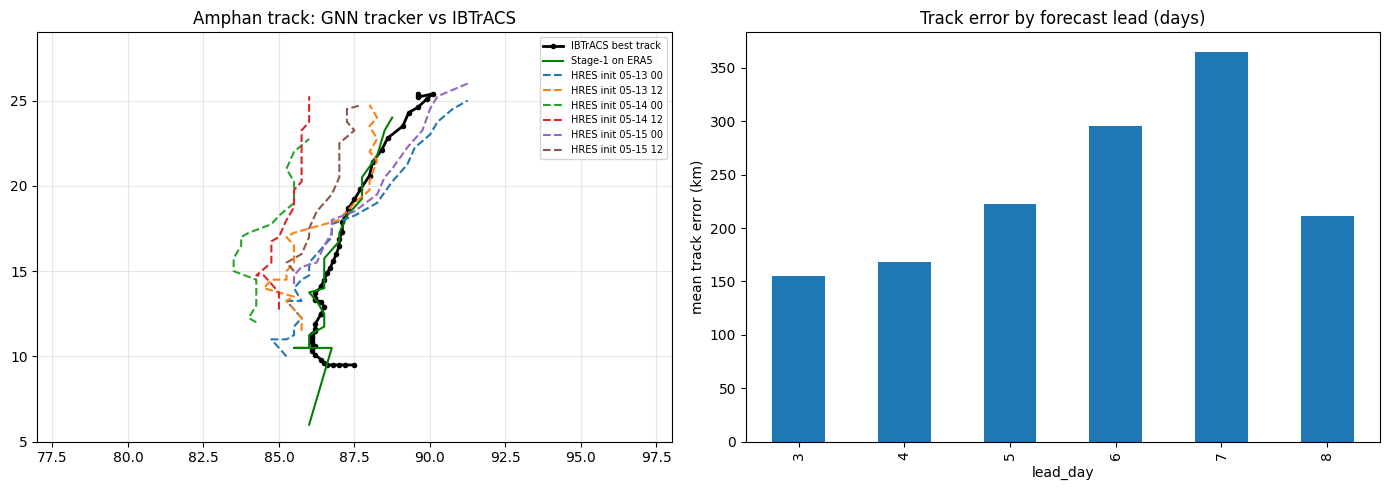

saved anomaly_track.json | severity: severe


In [6]:
# ============ 6. STAGE 1 - TRACK AMPHAN + VALIDATE VS IBTrACS ============
def arr(ds, v, dims): return ds[v].transpose(*dims).values

# (a) tracker on ERA5 truth (upper bound + gives crop centres for Stage 2)
era5_fields = [(surf_ev.msl.values[i], surf_ev.u10.values[i], surf_ev.v10.values[i]) for i in range(len(surf_ev.time))]
era5_times = list(pd.DatetimeIndex(surf_ev.time.values))
era5_track = track_sequence(era5_fields, era5_times)
e_err = track_errors(era5_track, era5_times, bt)
print(f"ERA5-analysis tracker: detected {e_err[e_err.alive].detected.mean()*100:.0f}% of best-track times | mean error {e_err.err_km.mean():.0f} km")

# (b) tracker on IFS HRES forecasts, 3-10 day leads
dims = ("prediction_timedelta", "latitude", "longitude")
runs, hres_store, err_all = [], {}, []
for it in hres.time.values:
    h = hres.sel(time=it)
    times = [pd.Timestamp(it) + pd.Timedelta(l) for l in h.prediction_timedelta.values]
    fields = list(zip(arr(h, "msl", dims), arr(h, "u10", dims), arr(h, "v10", dims)))
    trk = track_sequence(fields, times)
    hres_store[str(pd.Timestamp(it))] = (times, fields, trk)
    e = track_errors(trk, times, bt); e["init"] = pd.Timestamp(it); e["lead_day"] = ((e.t - pd.Timestamp(it)).dt.total_seconds() // 86400).astype(int)
    err_all.append(e)
    runs.append(dict(init=str(pd.Timestamp(it)), trajectory=[
        dict(lat=d["lat"], lon=d["lon"], t=d["t"], lead_h=int((pd.Timestamp(d["t"]) - pd.Timestamp(it)).total_seconds() // 3600),
             bbox=d["bbox"], severity=d["severity"], min_msl_hpa=d["min_msl_hpa"], max_wind_ms=d["max_wind_ms"]) for d in trk if d]))
err_all = pd.concat(err_all)
alive = err_all[err_all.alive]
summary = alive.groupby("lead_day").agg(steps=("t", "size"), detected=("detected", "mean"), mean_err_km=("err_km", "mean"), median_err_km=("err_km", "median"))
print("\nHRES tracking vs IBTrACS (only times when Amphan exists in best track):"); print(summary.round(2).to_string())

# figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(bt.LON, bt.LAT, "k-o", ms=3, lw=2, label="IBTrACS best track")
ax[0].plot([d["lon"] for d in era5_track if d], [d["lat"] for d in era5_track if d], "g-", lw=1.5, label="Stage-1 on ERA5")
for r in runs:
    if r["trajectory"]: ax[0].plot([p["lon"] for p in r["trajectory"]], [p["lat"] for p in r["trajectory"]], "--", label="HRES init " + r["init"][5:13])
ax[0].set_xlim(WIDE["lon"]); ax[0].set_ylim(WIDE["lat"]); ax[0].grid(alpha=.3); ax[0].legend(fontsize=7); ax[0].set_title("Amphan track: GNN tracker vs IBTrACS")
summary.mean_err_km.plot.bar(ax=ax[1], color="tab:blue"); ax[1].set_ylabel("mean track error (km)"); ax[1].set_title("Track error by forecast lead (days)")
plt.tight_layout(); plt.savefig(f"{OUT}/stage1_track_vs_ibtracs.png", dpi=130); plt.show()

# interface-contract JSON for Person B / C
assert any(r["trajectory"] for r in runs), "HRES tracker detected nothing - check units/grid or lower the thr in detect()"
last = [r for r in runs if r["trajectory"]][-1]
lat_all = [p["bbox"][0] for p in last["trajectory"]] + [p["bbox"][1] for p in last["trajectory"]]
lon_all = [p["bbox"][2] for p in last["trajectory"]] + [p["bbox"][3] for p in last["trajectory"]]
contract = dict(event=EVENT, init=last["init"],
                bbox=[min(lat_all), max(lat_all), min(lon_all), max(lon_all)],
                trajectory=[dict(lat=p["lat"], lon=p["lon"], t=p["t"]) for p in last["trajectory"]],
                severity=max((p["severity"] for p in last["trajectory"]), key=SEV_RANK.get), runs=runs)
json.dump(contract, open(f"{OUT}/anomaly_track.json", "w"), indent=1)
print("saved anomaly_track.json | severity:", contract["severity"])

In [7]:
# ============ 7. STAGE 2 - PHYSICS-CONSTRAINED DIFFUSION DOWNSCALING ============
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
CH = ["msl", "u10", "v10"]
MU, SG = np.array([1000., 0., 0.]), np.array([15., 10., 10.])        # fixed, physically meaningful scaling
MU_t = torch.tensor(MU, dtype=torch.float32, device=dev).view(1, 3, 1, 1)
SG_t = torch.tensor(SG, dtype=torch.float32, device=dev).view(1, 3, 1, 1)

def stack3(ds): return np.stack([arr(ds, v, ("time", "latitude", "longitude")) for v in CH], 1)     # (T,3,NY,NX)
Xtr_phys = stack3(surf_tr)
Xt = torch.tensor((Xtr_phys - MU[None, :, None, None]) / SG[None, :, None, None], dtype=torch.float32, device=dev)
wmax = np.hypot(Xtr_phys[:, 1], Xtr_phys[:, 2]).reshape(len(Xtr_phys), -1)
peak_idx = [np.unravel_index(a.argmax(), (NY, NX)) for a in wmax]
storm_t = np.where(wmax.max(1) >= np.quantile(wmax.max(1), 0.9))[0]
print("stage-2 training frames:", len(Xt), "| storm-rich frames:", len(storm_t))

def get_batch(B, p_storm=0.5):
    xs = []
    for _ in range(B):
        if random.random() < p_storm:                                # oversample extreme events - the whole point
            t = int(np.random.choice(storm_t)); cy, cx = peak_idx[t]
            y0, x0 = cy - CROP // 2 + random.randint(-20, 20), cx - CROP // 2 + random.randint(-20, 20)
        else:
            t = random.randrange(len(Xt)); y0, x0 = random.randint(0, NY - CROP), random.randint(0, NX - CROP)
        y0, x0 = int(np.clip(y0, 0, NY - CROP)), int(np.clip(x0, 0, NX - CROP))
        xs.append(Xt[t, :, y0:y0 + CROP, x0:x0 + CROP])
    return torch.stack(xs)

def coarsen(x): return Fnn.avg_pool2d(x, SCALE)
def upsample(c): return Fnn.interpolate(c, scale_factor=SCALE, mode="bicubic", align_corners=False)
def to_phys(x): return x * SG_t + MU_t
def wind_speed(xp): return torch.sqrt(xp[:, 1] ** 2 + xp[:, 2] ** 2 + 1e-6)

with torch.no_grad():                                              # residual scale (fine minus upsampled-coarse)
    S_RES = torch.stack([(lambda x: (x - upsample(coarsen(x))).std((0, 2, 3)))(get_batch(32)) for _ in range(100)]).mean(0).view(1, 3, 1, 1)
print("residual scale per channel:", S_RES.flatten().cpu().numpy().round(3))

def make_unet(cin, cout):
    return UNet2DModel(sample_size=CROP, in_channels=cin, out_channels=cout, layers_per_block=2,
                       block_out_channels=(64, 128, 256, 256),
                       down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
                       up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D")).to(dev)

def physics_terms(xh, x, cs, k=8):
    """(1) scale-consistency / conservation: block-averaging the output must give back the coarse field.
       (2) extreme-amplitude: top-k wind speed and lowest-k pressure must match truth (fights peak smoothing)."""
    cons = Fnn.mse_loss(coarsen(xh), cs, reduction="none").mean((1, 2, 3))
    ph, pt = to_phys(xh), to_phys(x)
    wh = wind_speed(ph).flatten(1).topk(k).values.mean(1); wt = wind_speed(pt).flatten(1).topk(k).values.mean(1)
    mh = ph[:, 0].flatten(1).topk(k, largest=False).values.mean(1); mt = pt[:, 0].flatten(1).topk(k, largest=False).values.mean(1)
    return cons, ((wh - wt) / 10) ** 2 + ((mh - mt) / 15) ** 2

# ---- 7a. baseline: plain U-Net (MSE) ----
unet_base = make_unet(3, 3); opt = torch.optim.AdamW(unet_base.parameters(), 2e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, UNET_STEPS)
zeros = lambda B: torch.zeros(B, dtype=torch.long, device=dev)
for i in range(UNET_STEPS):
    x = get_batch(32); c = upsample(coarsen(x)); r = (x - c) / S_RES
    loss = Fnn.mse_loss(unet_base(c, zeros(len(x))).sample, r)
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(unet_base.parameters(), 1.0); opt.step(); sch.step()
    if i % 500 == 0: print(f"U-Net baseline step {i:5d}  mse {loss.item():.4f}")
unet_base.eval(); torch.save(unet_base.state_dict(), f"{OUT}/unet_baseline.pt")

# ---- 7b. conditional diffusion (predicts the residual) + physics losses ----
T_STEPS, LAM_CONS, LAM_PEAK = 1000, 2.0, 0.5
sched = DDPMScheduler(num_train_timesteps=T_STEPS, beta_schedule="squaredcos_cap_v2")
ac = sched.alphas_cumprod.to(dev)
diff_unet = make_unet(6, 3); opt = torch.optim.AdamW(diff_unet.parameters(), 2e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, DIFF_STEPS)
for i in range(DIFF_STEPS):
    x = get_batch(32); cs = coarsen(x); c = upsample(cs); r = (x - c) / S_RES
    t = torch.randint(0, T_STEPS, (len(x),), device=dev); n = torch.randn_like(r)
    rt = sched.add_noise(r, n, t)
    eps = diff_unet(torch.cat([rt, c], 1), t).sample
    l_eps = Fnn.mse_loss(eps, n)
    a = ac[t].view(-1, 1, 1, 1)
    r0 = ((rt - (1 - a).sqrt() * eps) / a.sqrt()).clamp(-6, 6)     # predicted clean residual
    cons, peak = physics_terms(c + r0 * S_RES, x, cs)
    w = a.view(-1)                                                  # trust physics terms only when the x0-estimate is reliable
    loss = l_eps + LAM_CONS * (w * cons).mean() + LAM_PEAK * (w * peak).mean()
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(diff_unet.parameters(), 1.0); opt.step(); sch.step()
    if i % 500 == 0: print(f"Diffusion step {i:5d}  eps {l_eps.item():.4f}  cons {(w*cons).mean().item():.4f}  peak {(w*peak).mean().item():.4f}")
diff_unet.eval(); torch.save(diff_unet.state_dict(), f"{OUT}/diffusion_downscaler.pt")

ddim = DDIMScheduler(num_train_timesteps=T_STEPS, beta_schedule="squaredcos_cap_v2", clip_sample=False)
@torch.no_grad()
def downscale_diffusion(c, members=N_MEMBERS, steps=SAMPLE_STEPS, seed=0):
    """c: upsampled coarse (B,3,H,W), normalised -> (M,B,3,H,W) generated fine-scale members."""
    outs = []
    for m in range(members):
        g = torch.Generator(device=dev).manual_seed(seed + m)
        r = torch.randn(c.shape, device=dev, generator=g); ddim.set_timesteps(steps)
        for t in ddim.timesteps:
            r = ddim.step(diff_unet(torch.cat([r, c], 1), t).sample, t, r, eta=0.0).prev_sample
        outs.append(c + r * S_RES)
    return torch.stack(outs)

@torch.no_grad()
def downscale_unet(c): return c + unet_base(c, zeros(len(c))).sample * S_RES

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


stage-2 training frames: 7320 | storm-rich frames: 732
residual scale per channel: [0.022 0.049 0.05 ]
U-Net baseline step     0  mse 1.0597
U-Net baseline step   500  mse 0.3003
U-Net baseline step  1000  mse 0.2175
U-Net baseline step  1500  mse 0.1761
U-Net baseline step  2000  mse 0.1829
U-Net baseline step  2500  mse 0.1906
Diffusion step     0  eps 1.0905  cons 0.0001  peak 0.0060
Diffusion step   500  eps 0.1952  cons 0.0000  peak 0.0008
Diffusion step  1000  eps 0.1687  cons 0.0000  peak 0.0002
Diffusion step  1500  eps 0.1414  cons 0.0000  peak 0.0005
Diffusion step  2000  eps 0.1781  cons 0.0000  peak 0.0023
Diffusion step  2500  eps 0.1189  cons 0.0000  peak 0.0043
Diffusion step  3000  eps 0.1983  cons 0.0000  peak 0.0003
Diffusion step  3500  eps 0.1376  cons 0.0000  peak 0.0040
Diffusion step  4000  eps 0.2031  cons 0.0000  peak 0.0054
Diffusion step  4500  eps 0.1674  cons 0.0000  peak 0.0012
Diffusion step  5000  eps 0.1173  cons 0.0000  peak 0.0002
Diffusion step  5500

Amphan hold-out, 16 intense 6-hourly frames (truth peak wind >= 20 m/s):
                           peak_wind_retention_pct  abs_min_msl_err_hpa  wind_rmse_ms
Coarse (bicubic)                         88.849998                 7.23          0.74
Plain U-Net                              95.510002                 1.49          0.45
Diffusion (1 sample)                     98.489998                 1.78          0.59
Diffusion (ensemble mean)                97.089996                 1.80          0.49


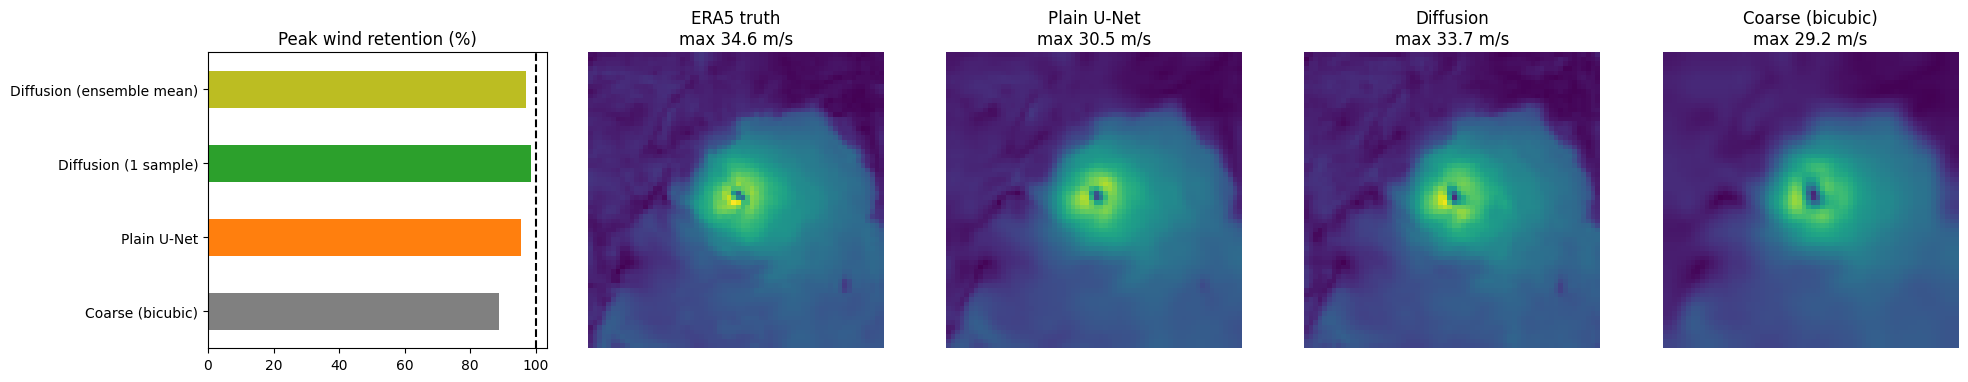

In [8]:
# ============ 8. STAGE 2 VALIDATION on Amphan hold-out: peak-amplitude retention vs U-Net ============
def crop_at(a, lat0, lon0):
    iy, ix = int(np.abs(LAT - lat0).argmin()), int(np.abs(LON - lon0).argmin())
    y0, x0 = int(np.clip(iy - CROP // 2, 0, NY - CROP)), int(np.clip(ix - CROP // 2, 0, NX - CROP))
    return a[..., y0:y0 + CROP, x0:x0 + CROP], (y0, x0)

ev_phys = stack3(surf_ev)
crops, tags = [], []
for k, d in enumerate(era5_track):
    if d is not None:
        crops.append(crop_at(ev_phys[k], d["lat"], d["lon"])[0]); tags.append(era5_times[k])
Xe = torch.tensor((np.stack(crops) - MU[None, :, None, None]) / SG[None, :, None, None], dtype=torch.float32, device=dev)
Ce = upsample(coarsen(Xe))
P_unet, P_diff = downscale_unet(Ce), downscale_diffusion(Ce)          # (B,3,H,W), (M,B,3,H,W)

def metrics(pred, truth):
    p, t = to_phys(pred), to_phys(truth)
    ret = 100 * wind_speed(p).flatten(1).max(1).values / wind_speed(t).flatten(1).max(1).values
    dmsl = (p[:, 0].flatten(1).min(1).values - t[:, 0].flatten(1).min(1).values).abs()
    rmse = ((p[:, 1:] - t[:, 1:]) ** 2).mean((1, 2, 3)).sqrt()
    return ret.cpu().numpy(), dmsl.cpu().numpy(), rmse.cpu().numpy()

truth_peak = wind_speed(to_phys(Xe)).flatten(1).max(1).values.cpu().numpy()
intense = truth_peak >= 20
if intense.sum() < 3: intense = np.ones_like(intense, dtype=bool)
res = {"Coarse (bicubic)": metrics(Ce, Xe), "Plain U-Net": metrics(P_unet, Xe),
       "Diffusion (1 sample)": tuple(np.mean([metrics(P_diff[m], Xe)[j] for m in range(N_MEMBERS)], 0) for j in range(3)),
       "Diffusion (ensemble mean)": metrics(P_diff.mean(0), Xe)}
tbl = pd.DataFrame({k: dict(peak_wind_retention_pct=v[0][intense].mean(), abs_min_msl_err_hpa=v[1][intense].mean(), wind_rmse_ms=v[2][intense].mean())
                    for k, v in res.items()}).T.round(2)
print(f"Amphan hold-out, {int(intense.sum())} intense 6-hourly frames (truth peak wind >= 20 m/s):"); print(tbl.to_string())
PEAK_SCORE = float(tbl.loc["Diffusion (1 sample)", "peak_wind_retention_pct"])

fig, ax = plt.subplots(1, 5, figsize=(20, 3.8))
tbl.peak_wind_retention_pct.plot.barh(ax=ax[0], color=["gray", "tab:orange", "tab:green", "tab:olive"]); ax[0].axvline(100, c="k", ls="--"); ax[0].set_title("Peak wind retention (%)")
kk = int(np.argmax(truth_peak)); ws = lambda z: wind_speed(to_phys(z[None] if z.dim() == 3 else z)).cpu().numpy()[0]
for a_, (nm, fld) in zip(ax[1:], [("ERA5 truth", Xe[kk]), ("Plain U-Net", P_unet[kk]), ("Diffusion", P_diff[0, kk]), ("Coarse (bicubic)", Ce[kk])]):
    im = a_.imshow(ws(fld), origin="lower", vmin=0, vmax=max(20, truth_peak[kk])); a_.set_title(f"{nm}\nmax {ws(fld).max():.1f} m/s"); a_.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT}/stage2_peak_retention.png", dpi=130); plt.show()

In [9]:
# ============ 9. END-TO-END DEMO + OUTPUT FILES for the API / dashboard ============
init_key = [k for k, (_, _, trk) in hres_store.items() if any(trk)][-1]
times, fields, trk = hres_store[init_key]
kbest = int(np.argmin([d["min_msl_hpa"] if d else 1e9 for d in trk]))
d = trk[kbest]
fine_crop, (y0, x0) = crop_at(np.stack(fields[kbest]), d["lat"], d["lon"])              # 3,64,64 HRES 0.25 deg
xin = torch.tensor((fine_crop - MU[:, None, None]) / SG[:, None, None], dtype=torch.float32, device=dev)[None]
Cd = upsample(coarsen(xin))                                                              # emulate a coarse ensemble product
out = downscale_diffusion(Cd, members=N_MEMBERS)                                         # (M,1,3,H,W)
phys = to_phys(out[:, 0]).cpu().numpy()                                                  # (M,3,H,W)
wsp = np.hypot(phys[:, 1], phys[:, 2])
sev_grid = np.where(wsp.mean(0) >= 24.5, 2, np.where(wsp.mean(0) >= 17.0, 1, 0))        # 0 low / 1 moderate / 2 severe
np.savez_compressed(f"{OUT}/downscaled_field.npz", lat=LAT[y0:y0 + CROP], lon=LON[x0:x0 + CROP], members=phys, severity_grid=sev_grid)
alert = dict(event=EVENT, forecast_init=init_key, valid_time=d["t"], centroid=dict(lat=d["lat"], lon=d["lon"]),
             bbox=d["bbox"], severity=d["severity"], peak_amplitude_score=PEAK_SCORE,
             downscaled_peak_wind_ms=float(wsp.reshape(len(wsp), -1).max(1).mean()),
             raw_hres_peak_wind_ms=float(np.hypot(fine_crop[1], fine_crop[2]).max()),
             cells_moderate=int((sev_grid == 1).sum()), cells_severe=int((sev_grid == 2).sum()))
json.dump(alert, open(f"{OUT}/alert.json", "w"), indent=1)
json.dump(dict(peak_amplitude_score=PEAK_SCORE, table=tbl.to_dict("index")), open(f"{OUT}/stage2_metrics.json", "w"), indent=1)
print(json.dumps(alert, indent=1))
print("\nFiles in /kaggle/working:", os.listdir(OUT))

{
 "event": "AMPHAN",
 "forecast_init": "2020-05-15 12:00:00",
 "valid_time": "2020-05-19 18:00:00",
 "centroid": {
  "lat": 18.5,
  "lon": 86.25
 },
 "bbox": [
  14.5,
  22.25,
  80.75,
  90.75
 ],
 "severity": "severe",
 "peak_amplitude_score": 98.48999786376953,
 "downscaled_peak_wind_ms": 34.163185119628906,
 "raw_hres_peak_wind_ms": 43.49956130981445,
 "cells_moderate": 139,
 "cells_severe": 64
}

Files in /kaggle/working: ['gnn_tracker.pt', 'alert.json', 'unet_baseline.pt', 'stage2_metrics.json', 'downscaled_field.npz', 'anomaly_track.json', 'diffusion_downscaler.pt', '__notebook__.ipynb', 'stage2_peak_retention.png', 'stage1_track_vs_ibtracs.png']
